In [1]:
# ============================================================
# PHASE 3 — EDA + SENTIMENT ANALYSIS
# ============================================================
# WHY EDA FIRST:
# Before building any AI model or dashboard you must
# visually understand your data. EDA reveals patterns,
# outliers, distributions and relationships that numbers
# alone cannot show. Every chart here becomes a slide
# in your final presentation and a panel in your dashboard.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

# Set visual style for all matplotlib charts
# darkgrid gives clean readable charts
# palette gives consistent colours throughout
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"]     = 120

# ── Load all cleaned datasets ────────────────────────────────
instagram_df  = pd.read_csv("data/cleaned/instagram_clean.csv")
trends_df     = pd.read_csv("data/cleaned/trends_clean.csv")
retail_df     = pd.read_csv("data/cleaned/retail_clean.csv")
consumers_df  = pd.read_csv("data/cleaned/chennai_consumers.csv")
posts_df      = pd.read_csv("data/cleaned/chennai_social_posts.csv")
stores_df     = pd.read_csv("data/cleaned/chennai_stores.csv")
monthly_df    = pd.read_csv("data/cleaned/monthly_trends.csv")
master_df     = pd.read_csv("data/cleaned/master_merged.csv")
locality_df   = pd.read_csv("data/cleaned/locality_summary.csv")

# Convert date columns
instagram_df["post_date"] = pd.to_datetime(instagram_df["post_date"])
trends_df["post_date"]    = pd.to_datetime(trends_df["post_date"])
monthly_df["month_date"]  = pd.to_datetime(monthly_df["month_date"])

print("✅ All datasets loaded for Phase 3")
print()
print(f"   Instagram     : {len(instagram_df):>6} rows")
print(f"   Trends        : {len(trends_df):>6} rows")
print(f"   Retail        : {len(retail_df):>6} rows")
print(f"   Consumers     : {len(consumers_df):>6} rows")
print(f"   Chennai Posts : {len(posts_df):>6} rows")
print(f"   Stores        : {len(stores_df):>6} rows")
print(f"   Monthly Trends: {len(monthly_df):>6} rows")
print(f"   Master Table  : {len(master_df):>6} rows")

✅ All datasets loaded for Phase 3

   Instagram     :  29999 rows
   Trends        :   5000 rows
   Retail        :   1000 rows
   Consumers     :   5000 rows
   Chennai Posts :   3000 rows
   Stores        :    200 rows
   Monthly Trends:    216 rows
   Master Table  :      4 rows


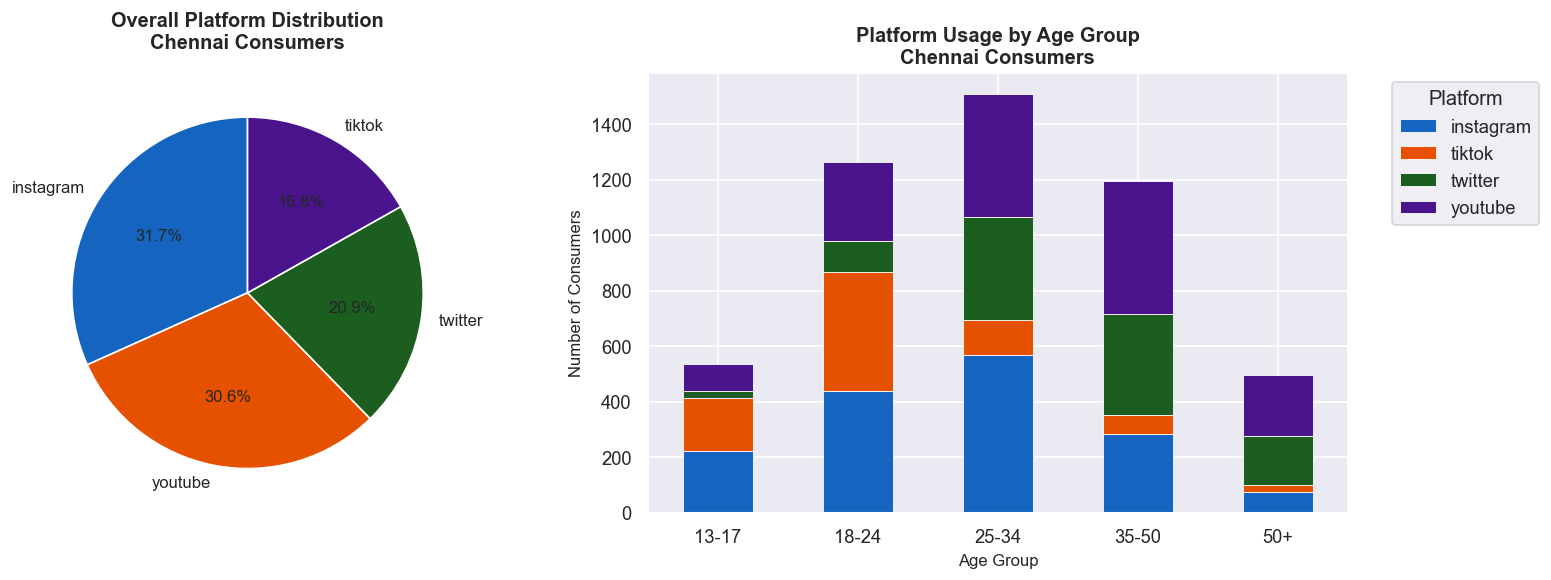

✅ Chart 1 saved


In [2]:
# ============================================================
# CHART 1 — Platform Popularity by Age Group
# ============================================================
# WHY THIS CHART:
# This is the foundation of your entire project insight.
# It shows which age group dominates which platform.
# This visual alone answers — "who is watching where"
# before we even connect it to purchases.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left chart: Platform distribution overall ────────────────
platform_counts = consumers_df["primary_platform"].value_counts()
colors_platform = ["#1565C0", "#E65100", "#1B5E20", "#4A148C"]

axes[0].pie(
    platform_counts.values,
    labels=platform_counts.index,
    colors=colors_platform,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 10}
)
axes[0].set_title("Overall Platform Distribution\nChennai Consumers",
                   fontsize=12, fontweight="bold", pad=15)

# ── Right chart: Platform by age group (stacked bar) ─────────
platform_age = consumers_df.groupby(
    ["age_group", "primary_platform"]
).size().unstack(fill_value=0)

# Order age groups correctly
age_order = ["13-17", "18-24", "25-34", "35-50", "50+"]
platform_age = platform_age.reindex(age_order)

platform_age.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=colors_platform,
    edgecolor="white",
    linewidth=0.5
)
axes[1].set_title("Platform Usage by Age Group\nChennai Consumers",
                   fontsize=12, fontweight="bold")
axes[1].set_xlabel("Age Group", fontsize=10)
axes[1].set_ylabel("Number of Consumers", fontsize=10)
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Platform", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("data/cleaned/chart1_platform_by_age.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 1 saved")

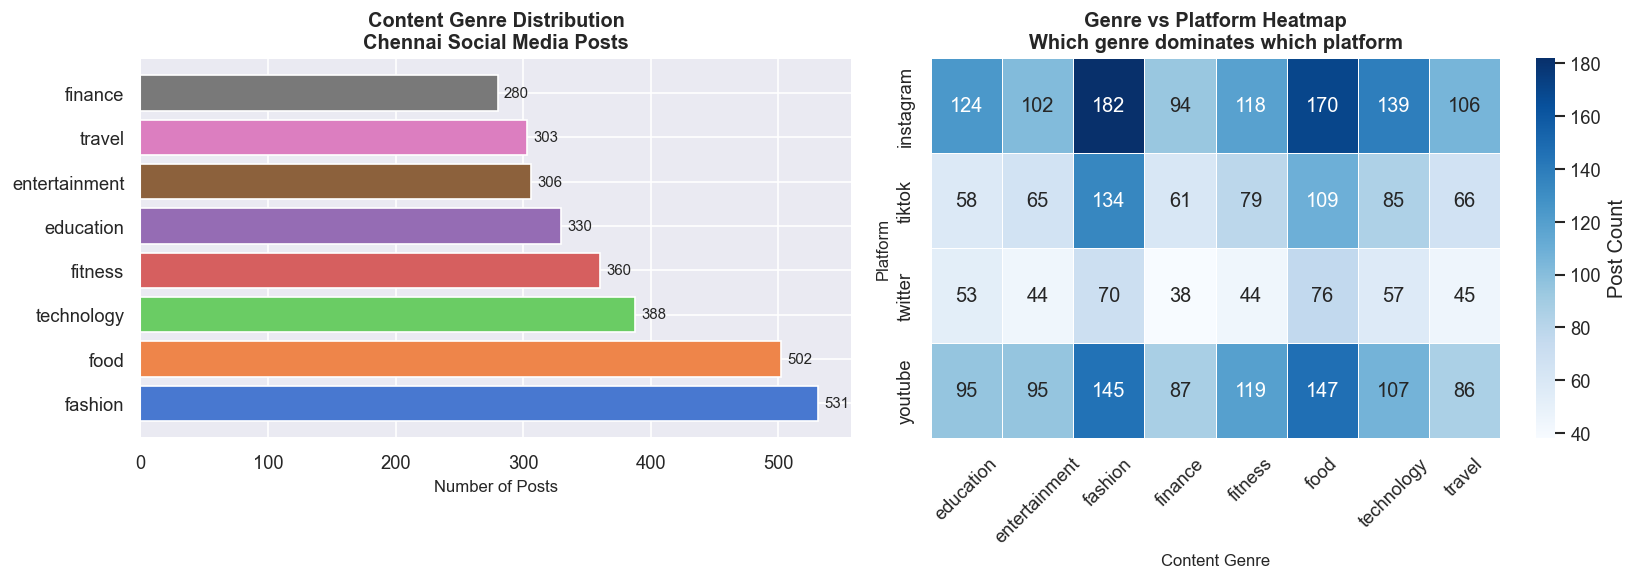

✅ Chart 2 saved


In [3]:
# ============================================================
# CHART 2 — Content Genre Popularity
# ============================================================
# WHY THIS CHART:
# Shows which content genres dominate Chennai social media.
# Combined with the platform chart it tells you not just
# WHERE people watch but WHAT they watch.
# This feeds directly into the purchase correlation analysis.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Genre distribution from Chennai posts ──────────────
genre_counts = posts_df["content_genre"].value_counts()
colors_genre = sns.color_palette("muted", len(genre_counts))

bars = axes[0].barh(
    genre_counts.index,
    genre_counts.values,
    color=colors_genre,
    edgecolor="white"
)
axes[0].set_title("Content Genre Distribution\nChennai Social Media Posts",
                   fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Posts", fontsize=10)

# Add value labels on bars
for bar, val in zip(bars, genre_counts.values):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 str(val), va="center", fontsize=9)

# ── Right: Genre by platform heatmap ─────────────────────────
genre_platform = posts_df.groupby(
    ["platform", "content_genre"]
).size().unstack(fill_value=0)

sns.heatmap(
    genre_platform,
    ax=axes[1],
    cmap="Blues",
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Post Count"}
)
axes[1].set_title("Genre vs Platform Heatmap\nWhich genre dominates which platform",
                   fontsize=12, fontweight="bold")
axes[1].set_xlabel("Content Genre", fontsize=10)
axes[1].set_ylabel("Platform", fontsize=10)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("data/cleaned/chart2_genre_popularity.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 2 saved")

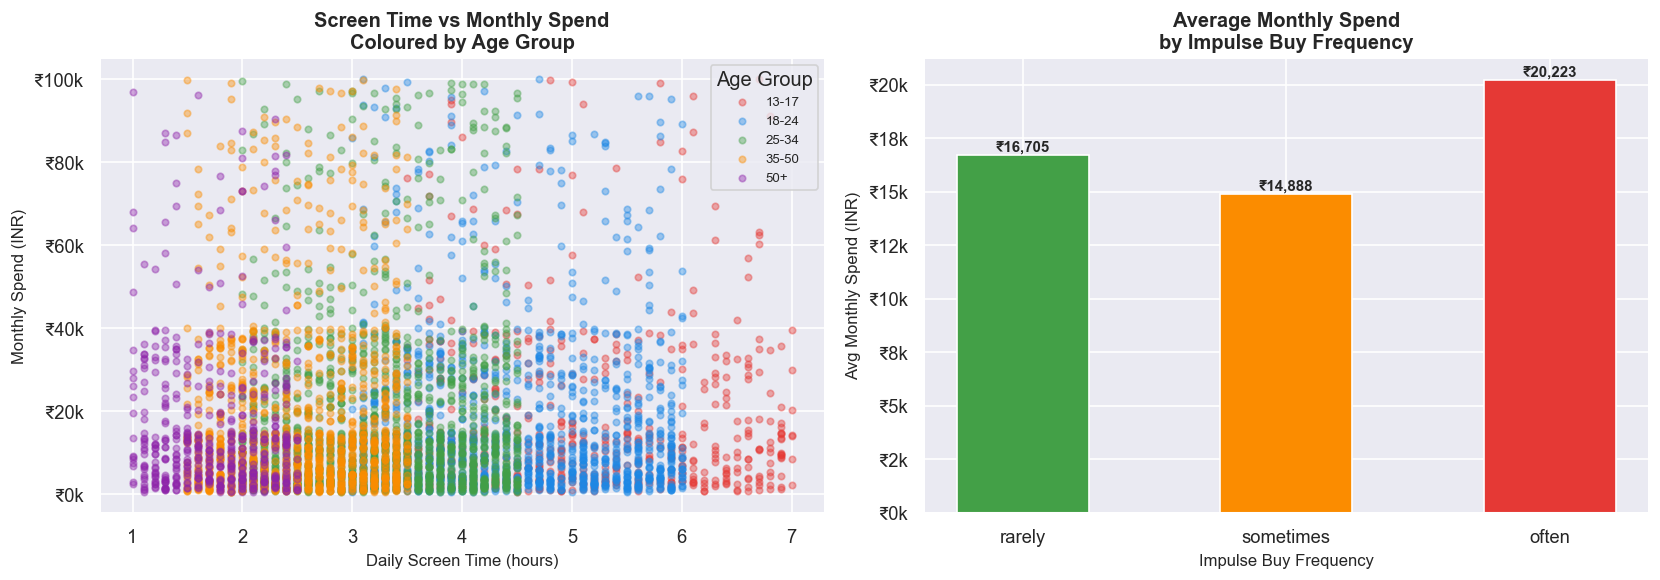

✅ Chart 3 saved


In [4]:
# ============================================================
# CHART 3 — Screen Time vs Monthly Spending
# ============================================================
# WHY THIS CHART:
# This is the most important EDA chart in your project.
# It visually tests your core hypothesis — does higher
# screen time lead to higher spending?
# If the scatter shows an upward trend your hypothesis
# is supported by data before any ML model runs.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Scatter — screen time vs monthly spend ─────────────
age_colors = {
    "13-17": "#E53935",
    "18-24": "#1E88E5",
    "25-34": "#43A047",
    "35-50": "#FB8C00",
    "50+":   "#8E24AA"
}

for age_grp, color in age_colors.items():
    subset = consumers_df[consumers_df["age_group"] == age_grp]
    axes[0].scatter(
        subset["daily_screen_time_hrs"],
        subset["monthly_spend_inr"],
        alpha=0.4,
        s=15,
        color=color,
        label=age_grp
    )

axes[0].set_title("Screen Time vs Monthly Spend\nColoured by Age Group",
                   fontsize=12, fontweight="bold")
axes[0].set_xlabel("Daily Screen Time (hours)", fontsize=10)
axes[0].set_ylabel("Monthly Spend (INR)", fontsize=10)
axes[0].legend(title="Age Group", fontsize=8)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"₹{x/1000:.0f}k")
)

# ── Right: Average spend by impulse buy frequency ────────────
impulse_spend = consumers_df.groupby("impulse_buy_freq")[
    "monthly_spend_inr"
].mean().reindex(["rarely", "sometimes", "often"])

colors_impulse = ["#43A047", "#FB8C00", "#E53935"]
bars = axes[1].bar(
    impulse_spend.index,
    impulse_spend.values,
    color=colors_impulse,
    edgecolor="white",
    width=0.5
)
axes[1].set_title("Average Monthly Spend\nby Impulse Buy Frequency",
                   fontsize=12, fontweight="bold")
axes[1].set_xlabel("Impulse Buy Frequency", fontsize=10)
axes[1].set_ylabel("Avg Monthly Spend (INR)", fontsize=10)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"₹{x/1000:.0f}k")
)

for bar, val in zip(bars, impulse_spend.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f"₹{val:,.0f}",
        ha="center", fontsize=9, fontweight="bold"
    )

plt.tight_layout()
plt.savefig("data/cleaned/chart3_screentime_vs_spend.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 3 saved")

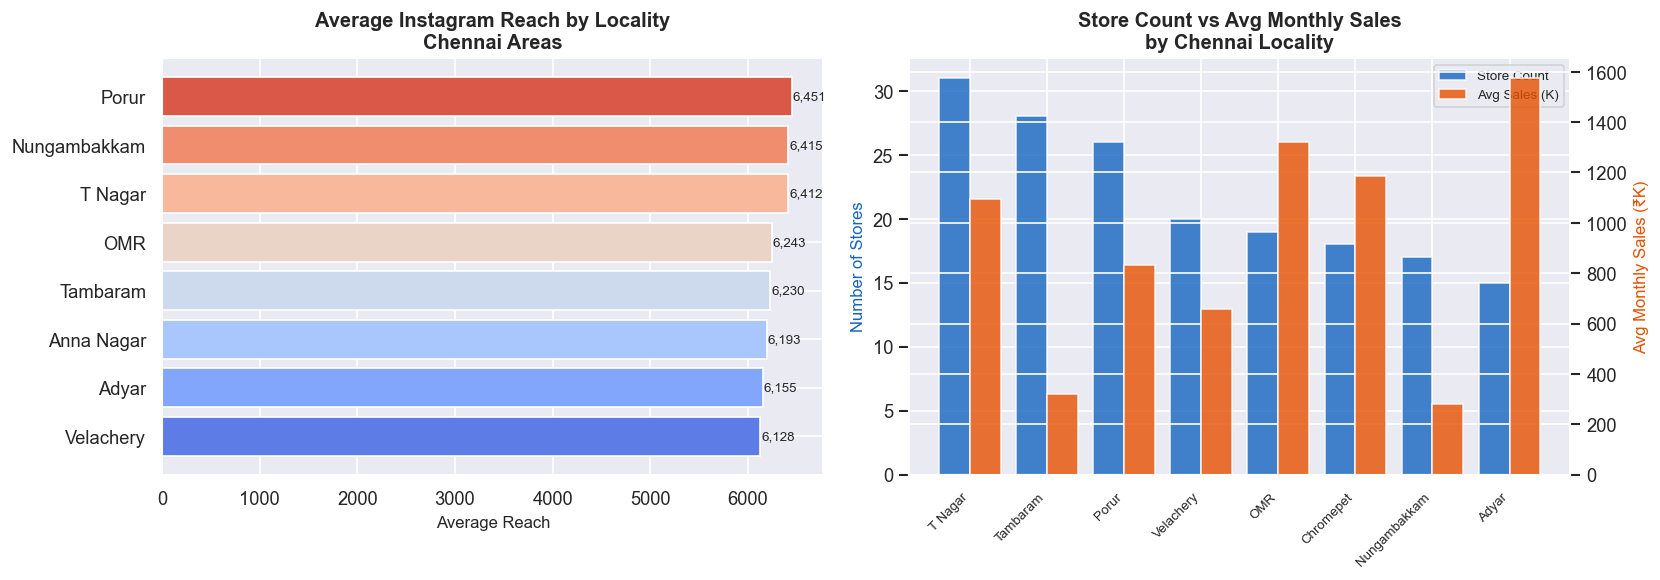

✅ Chart 4 saved


In [5]:
# ============================================================
# CHART 4 — Locality Level Analysis
# ============================================================
# WHY THIS CHART:
# This makes your project Chennai-specific not just generic.
# It shows which localities have highest engagement,
# which areas have most stores, and which neighbourhoods
# are the most commercially active.
# This is the hyperlocal intelligence layer.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Average reach by locality from Instagram ───────────
locality_reach = locality_df.groupby("locality")[
    "avg_reach"
].mean().sort_values(ascending=True)

colors_loc = sns.color_palette("coolwarm", len(locality_reach))
bars = axes[0].barh(
    locality_reach.index,
    locality_reach.values,
    color=colors_loc,
    edgecolor="white"
)
axes[0].set_title("Average Instagram Reach by Locality\nChennai Areas",
                   fontsize=12, fontweight="bold")
axes[0].set_xlabel("Average Reach", fontsize=10)

for bar, val in zip(bars, locality_reach.values):
    axes[0].text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height()/2,
        f"{val:,.0f}",
        va="center", fontsize=8
    )

# ── Right: Store count and avg sales by locality ─────────────
store_locality = stores_df.groupby("locality").agg(
    store_count        = ("store_id",              "count"),
    avg_monthly_sales  = ("avg_monthly_sales_inr", "mean")
).sort_values("store_count", ascending=False).head(8)

x      = range(len(store_locality))
width  = 0.4

ax2 = axes[1].twinx()

axes[1].bar(
    [i - width/2 for i in x],
    store_locality["store_count"],
    width=width,
    color="#1565C0",
    alpha=0.8,
    label="Store Count"
)
ax2.bar(
    [i + width/2 for i in x],
    store_locality["avg_monthly_sales"] / 1000,
    width=width,
    color="#E65100",
    alpha=0.8,
    label="Avg Sales (K)"
)

axes[1].set_xticks(list(x))
axes[1].set_xticklabels(store_locality.index, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Number of Stores", color="#1565C0", fontsize=10)
ax2.set_ylabel("Avg Monthly Sales (₹K)", color="#E65100", fontsize=10)
axes[1].set_title("Store Count vs Avg Monthly Sales\nby Chennai Locality",
                   fontsize=12, fontweight="bold")

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2,
               loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("data/cleaned/chart4_locality_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 4 saved")

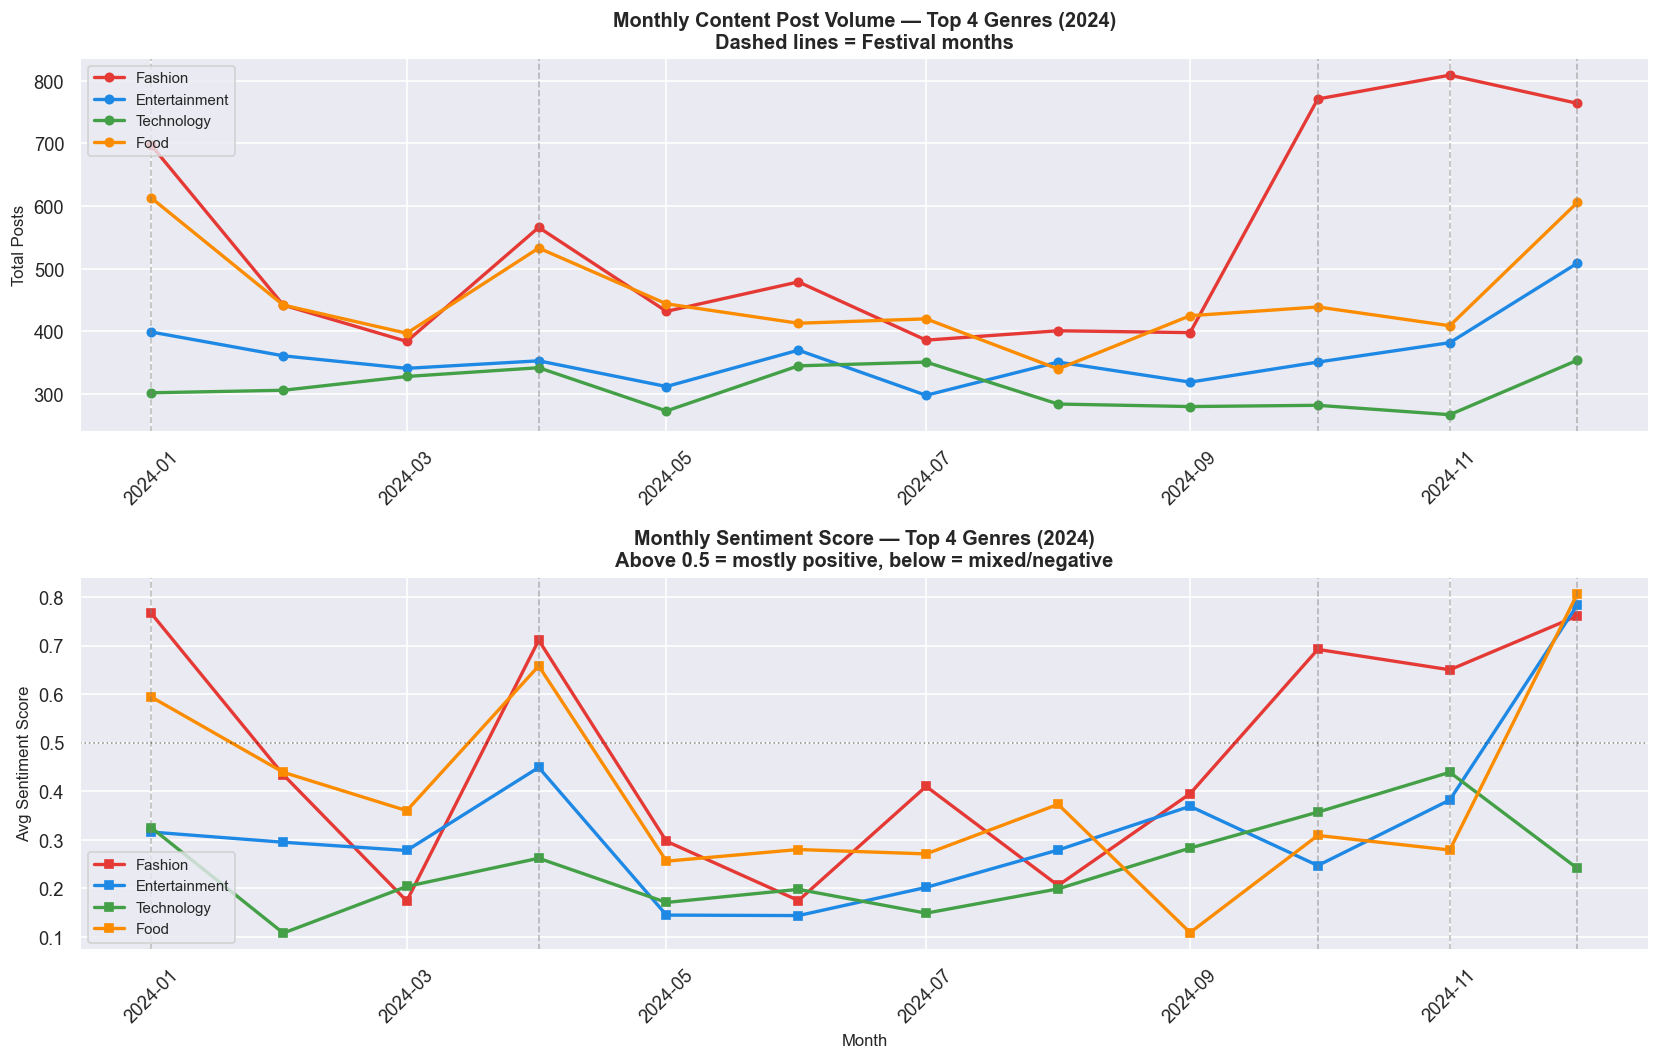

✅ Chart 5 saved


In [6]:
# ============================================================
# CHART 5 — Monthly Content Trends (Time Series)
# ============================================================
# WHY THIS CHART:
# This is the only chart that shows CHANGE OVER TIME.
# It reveals seasonal patterns — festival spikes,
# mid-year dips, year-end surges.
# A dashboard that shows trends over time is far more
# valuable than one showing static snapshots.
# ============================================================

social_monthly = monthly_df[
    monthly_df["record_type"] == "social_media"
].copy()

# Pick top 4 genres to keep chart readable
top_genres = ["fashion", "entertainment", "technology", "food"]
colors_ts  = ["#E53935", "#1E88E5", "#43A047", "#FB8C00"]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# ── Top: Post volume over time ────────────────────────────────
for genre, color in zip(top_genres, colors_ts):
    data = social_monthly[social_monthly["category"] == genre]
    axes[0].plot(
        data["month_date"],
        data["total_posts"],
        marker="o",
        color=color,
        linewidth=2,
        markersize=5,
        label=genre.title()
    )

# Mark festival months
festival_months = ["2024-01-01", "2024-04-01",
                   "2024-10-01", "2024-11-01", "2024-12-01"]
for fm in festival_months:
    axes[0].axvline(
        pd.Timestamp(fm),
        color="gray",
        linestyle="--",
        alpha=0.5,
        linewidth=1
    )

axes[0].set_title("Monthly Content Post Volume — Top 4 Genres (2024)\n"
                   "Dashed lines = Festival months",
                   fontsize=12, fontweight="bold")
axes[0].set_ylabel("Total Posts", fontsize=10)
axes[0].legend(loc="upper left", fontsize=9)
axes[0].tick_params(axis="x", rotation=45)

# ── Bottom: Sentiment score over time ────────────────────────
for genre, color in zip(top_genres, colors_ts):
    data = social_monthly[social_monthly["category"] == genre]
    axes[1].plot(
        data["month_date"],
        data["sentiment_score"],
        marker="s",
        color=color,
        linewidth=2,
        markersize=5,
        label=genre.title()
    )

for fm in festival_months:
    axes[1].axvline(
        pd.Timestamp(fm),
        color="gray",
        linestyle="--",
        alpha=0.5,
        linewidth=1
    )

axes[1].axhline(0.5, color="black", linestyle=":", alpha=0.4, linewidth=1)
axes[1].set_title("Monthly Sentiment Score — Top 4 Genres (2024)\n"
                   "Above 0.5 = mostly positive, below = mixed/negative",
                   fontsize=12, fontweight="bold")
axes[1].set_ylabel("Avg Sentiment Score", fontsize=10)
axes[1].set_xlabel("Month", fontsize=10)
axes[1].legend(loc="lower left", fontsize=9)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("data/cleaned/chart5_monthly_trends.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 5 saved")

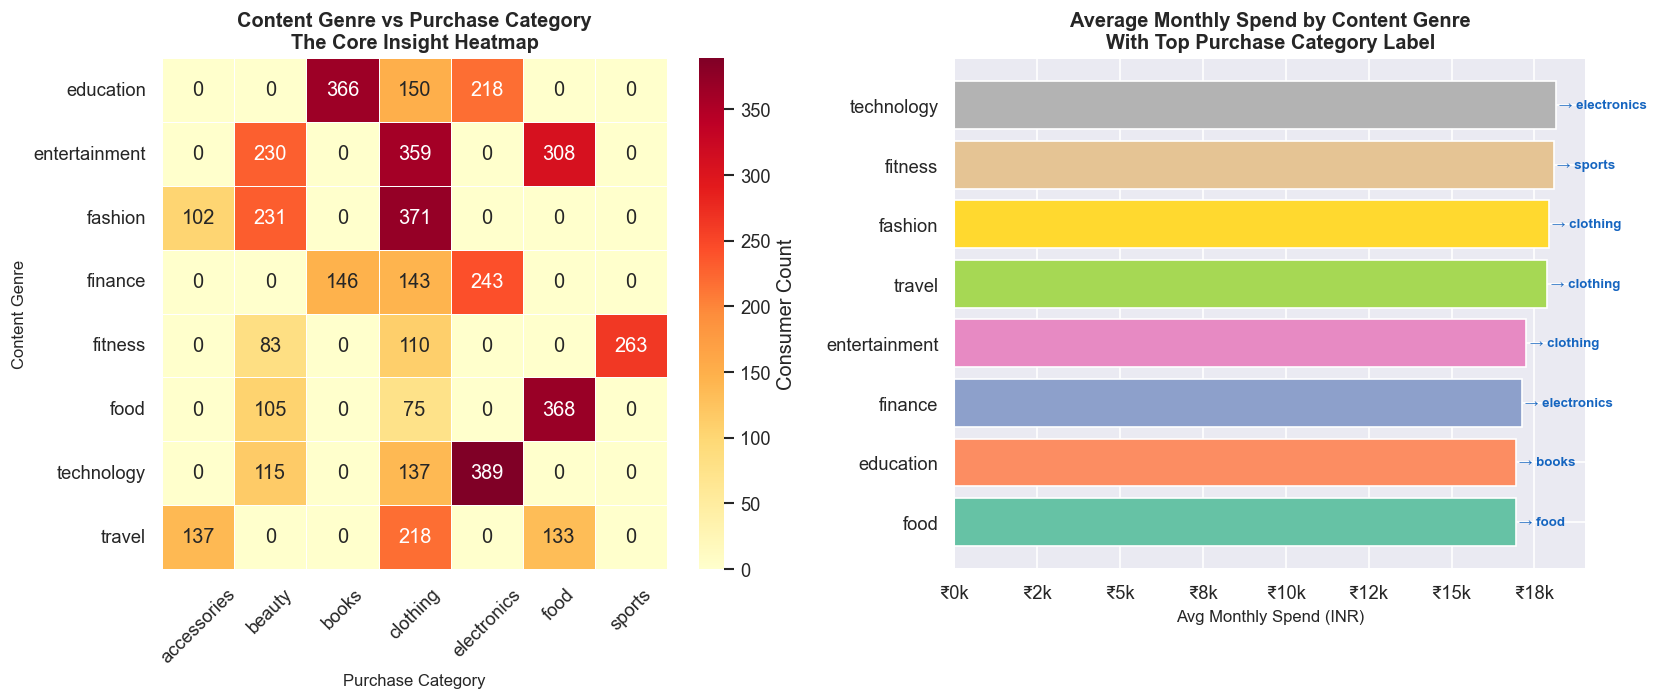

✅ Chart 6 saved


In [7]:
# ============================================================
# CHART 6 — Purchase Category by Content Genre
# ============================================================
# WHY THIS CHART:
# This is THE core insight chart of your entire project.
# It directly visualises the answer to your question —
# does what you watch influence what you buy?
# This chart goes on the front page of your dashboard.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Heatmap — genre vs purchase category ───────────────
genre_purchase = consumers_df.groupby(
    ["top_content_genre", "top_purchase_category"]
).size().unstack(fill_value=0)

sns.heatmap(
    genre_purchase,
    ax=axes[0],
    cmap="YlOrRd",
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Consumer Count"}
)
axes[0].set_title("Content Genre vs Purchase Category\nThe Core Insight Heatmap",
                   fontsize=12, fontweight="bold")
axes[0].set_xlabel("Purchase Category", fontsize=10)
axes[0].set_ylabel("Content Genre", fontsize=10)
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

# ── Right: Top purchase per genre (cleaner bar view) ─────────
top_purchase_per_genre = consumers_df.groupby("top_content_genre")[
    "top_purchase_category"
].agg(lambda x: x.value_counts().index[0]).reset_index()
top_purchase_per_genre.columns = ["genre", "top_purchase"]

genre_spend = consumers_df.groupby("top_content_genre")[
    "monthly_spend_inr"
].mean().reset_index()
genre_spend.columns = ["genre", "avg_spend"]

merged_insight = top_purchase_per_genre.merge(genre_spend, on="genre")
merged_insight = merged_insight.sort_values("avg_spend", ascending=True)

colors_bar = sns.color_palette("Set2", len(merged_insight))
bars = axes[1].barh(
    merged_insight["genre"],
    merged_insight["avg_spend"],
    color=colors_bar,
    edgecolor="white"
)
axes[1].set_title("Average Monthly Spend by Content Genre\nWith Top Purchase Category Label",
                   fontsize=12, fontweight="bold")
axes[1].set_xlabel("Avg Monthly Spend (INR)", fontsize=10)
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"₹{x/1000:.0f}k")
)

for bar, (_, row) in zip(bars, merged_insight.iterrows()):
    axes[1].text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height()/2,
        f"→ {row['top_purchase']}",
        va="center", fontsize=8, color="#1565C0", fontweight="bold"
    )

plt.tight_layout()
plt.savefig("data/cleaned/chart6_genre_vs_purchase.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 6 saved")

In [8]:
# ============================================================
# PART 2 — VADER SENTIMENT ANALYSIS — AI LAYER 1
# ============================================================
# WHY VADER FOR THIS PROJECT:
# VADER is specifically trained on social media language.
# It understands slang, emojis, capitalisation and
# punctuation as sentiment signals.
# "AMAZING!!!" scores higher than "amazing" because
# capitals and exclamation marks signal intensity.
# It runs locally — zero API cost, zero internet needed.
# ============================================================

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialise the analyser
# This loads VADER's internal dictionary of 7,500+ words
# each pre-scored for emotional valence
analyser = SentimentIntensityAnalyzer()

print("✅ VADER Sentiment Analyser loaded")
print()

# Test VADER on 3 example captions first
# So you can see exactly what it returns before running on all posts
test_captions = [
    "This biryani from Murugan Idli Shop is absolutely divine! 😍",
    "Overpriced and underwhelming — will not be returning",
    "Trying out a new aesthetic this week, let me know thoughts"
]

print("VADER test on 3 sample captions:")
print("-" * 55)
for caption in test_captions:
    scores = analyser.polarity_scores(caption)
    label  = "POSITIVE" if scores["compound"] >= 0.05 else \
             "NEGATIVE" if scores["compound"] <= -0.05 else "NEUTRAL"
    print(f"Caption  : {caption[:55]}...")
    print(f"Scores   : pos={scores['pos']:.3f}  "
          f"neg={scores['neg']:.3f}  "
          f"compound={scores['compound']:.3f}")
    print(f"Label    : {label}")
    print()

✅ VADER Sentiment Analyser loaded

VADER test on 3 sample captions:
-------------------------------------------------------
Caption  : This biryani from Murugan Idli Shop is absolutely divin...
Scores   : pos=0.404  neg=0.000  compound=0.816
Label    : POSITIVE

Caption  : Overpriced and underwhelming — will not be returning...
Scores   : pos=0.000  neg=0.000  compound=0.000
Label    : NEUTRAL

Caption  : Trying out a new aesthetic this week, let me know thoug...
Scores   : pos=0.000  neg=0.000  compound=0.000
Label    : NEUTRAL



In [9]:
# ============================================================
# Run VADER on all 3000 Chennai social media posts
# ============================================================
# We apply VADER to every caption in our dataset
# This adds 4 new columns to posts_df:
# sentiment_positive, sentiment_negative,
# sentiment_neutral, sentiment_compound, sentiment_label
# ============================================================

def analyse_sentiment(caption):
    scores = analyser.polarity_scores(str(caption))
    label  = "positive" if scores["compound"] >= 0.05 else \
             "negative" if scores["compound"] <= -0.05 else "neutral"
    return pd.Series({
        "sent_positive": scores["pos"],
        "sent_negative": scores["neg"],
        "sent_neutral":  scores["neu"],
        "sent_compound": scores["compound"],
        "sent_label":    label
    })

# Apply to every row — this runs VADER on all 3000 captions
print("Running VADER on 3000 posts...")
sentiment_results = posts_df["caption"].apply(analyse_sentiment)
posts_df = pd.concat([posts_df, sentiment_results], axis=1)

print("✅ VADER complete")
print()
print(f"Sentiment distribution across 3000 posts:")
print(posts_df["sent_label"].value_counts())
print()
print(f"Average compound score overall : "
      f"{posts_df['sent_compound'].mean():.3f}")
print()
print("Average compound score by genre:")
genre_sentiment = posts_df.groupby("content_genre")[
    "sent_compound"
].mean().sort_values(ascending=False)
print(genre_sentiment.round(3))

Running VADER on 3000 posts...
✅ VADER complete

Sentiment distribution across 3000 posts:
sent_label
positive    1248
negative     887
neutral      865
Name: count, dtype: int64

Average compound score overall : 0.023

Average compound score by genre:
content_genre
education        0.156
fashion          0.114
food             0.071
fitness         -0.001
finance         -0.001
entertainment   -0.050
technology      -0.059
travel          -0.131
Name: sent_compound, dtype: float64


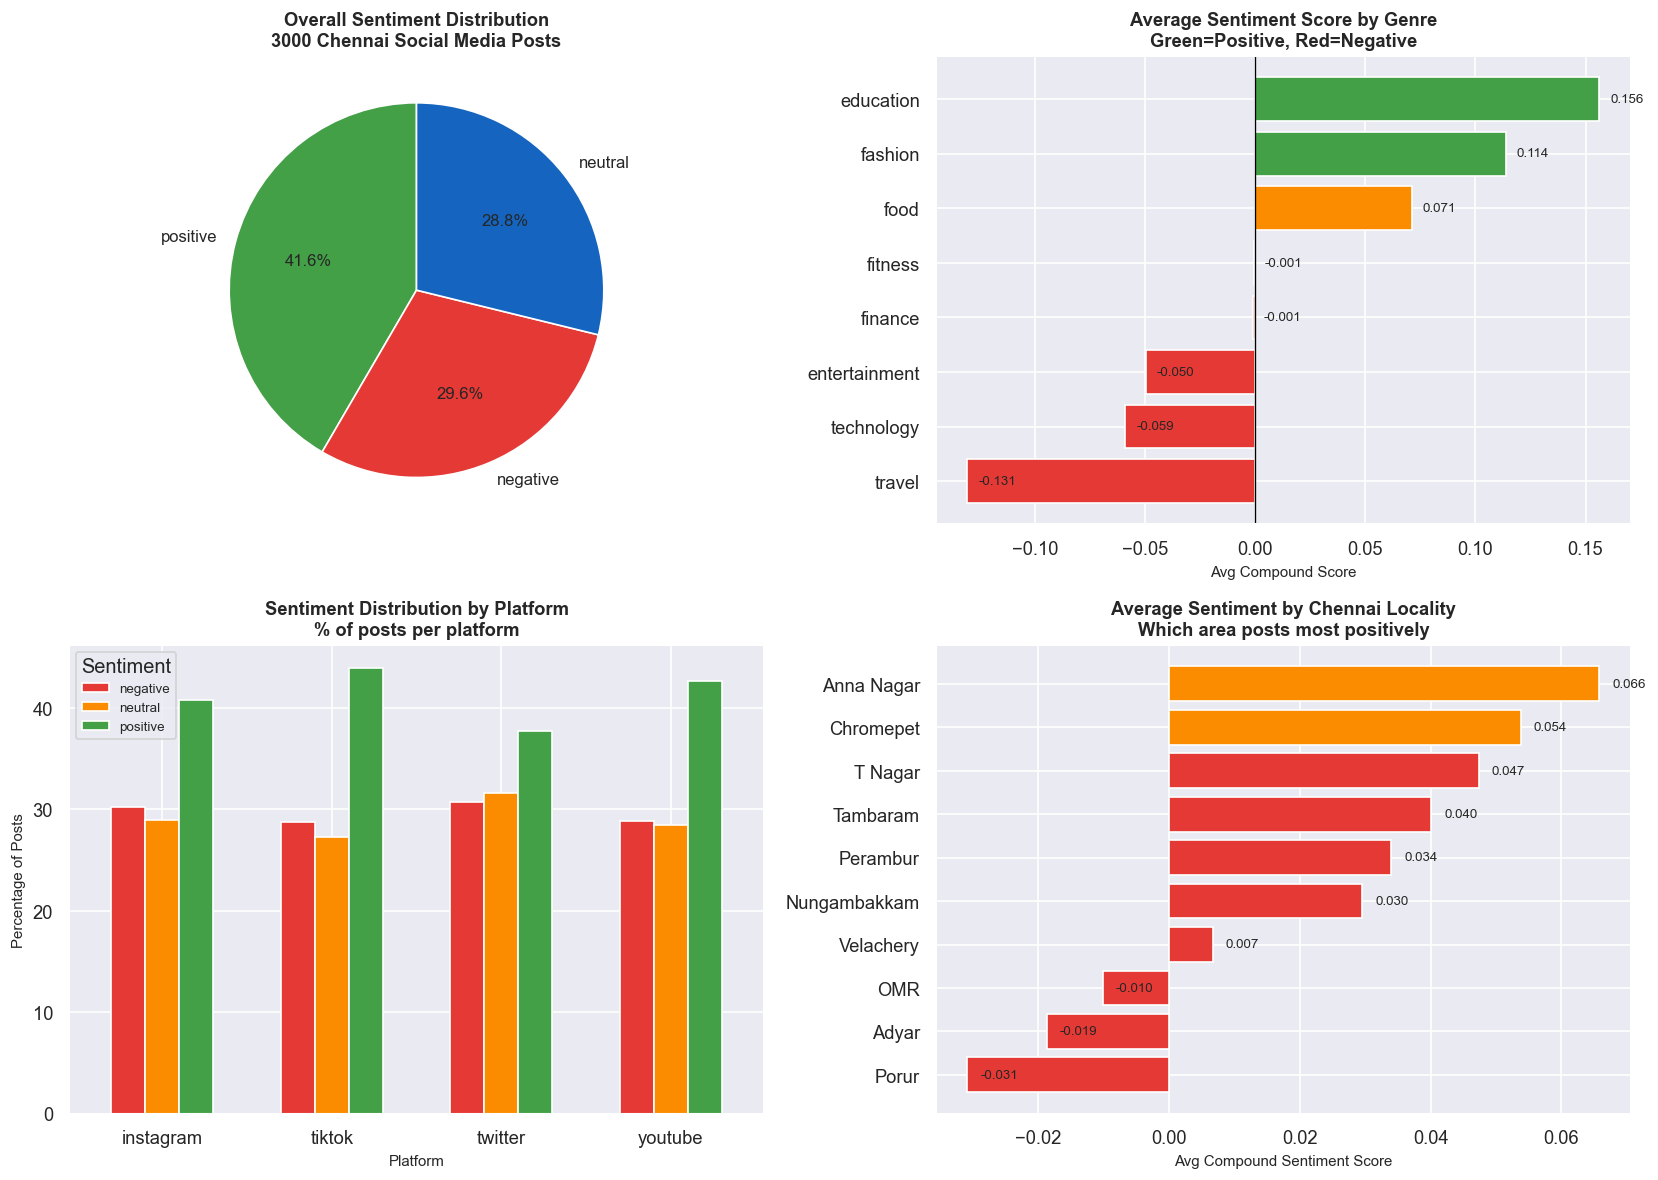

✅ Sentiment charts saved


In [10]:
# ============================================================
# SENTIMENT ANALYSIS CHARTS
# ============================================================
# These charts visualise what VADER found across all posts.
# Which genres are most positive? Which platforms generate
# most negativity? Which localities have most positive content?
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Chart A: Sentiment distribution overall ──────────────────
sent_counts = posts_df["sent_label"].value_counts()
colors_sent = ["#43A047", "#E53935", "#1565C0"]

axes[0,0].pie(
    sent_counts.values,
    labels=sent_counts.index,
    colors=colors_sent,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 10}
)
axes[0,0].set_title("Overall Sentiment Distribution\n3000 Chennai Social Media Posts",
                     fontsize=11, fontweight="bold")

# ── Chart B: Average compound score by genre ─────────────────
genre_sent = posts_df.groupby("content_genre")[
    "sent_compound"
].mean().sort_values(ascending=True)

colors_bar = ["#E53935" if v < 0 else
              "#FB8C00" if v < 0.1 else
              "#43A047" for v in genre_sent.values]

bars = axes[0,1].barh(
    genre_sent.index,
    genre_sent.values,
    color=colors_bar,
    edgecolor="white"
)
axes[0,1].axvline(0, color="black", linewidth=0.8)
axes[0,1].set_title("Average Sentiment Score by Genre\nGreen=Positive, Red=Negative",
                     fontsize=11, fontweight="bold")
axes[0,1].set_xlabel("Avg Compound Score", fontsize=9)

for bar, val in zip(bars, genre_sent.values):
    axes[0,1].text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{val:.3f}",
        va="center", fontsize=8
    )

# ── Chart C: Sentiment by platform ───────────────────────────
platform_sent = posts_df.groupby(
    ["platform", "sent_label"]
).size().unstack(fill_value=0)

platform_sent_pct = platform_sent.div(
    platform_sent.sum(axis=1), axis=0
) * 100

platform_sent_pct.plot(
    kind="bar",
    ax=axes[1,0],
    color=["#E53935", "#FB8C00", "#43A047"],
    edgecolor="white",
    width=0.6
)
axes[1,0].set_title("Sentiment Distribution by Platform\n% of posts per platform",
                     fontsize=11, fontweight="bold")
axes[1,0].set_xlabel("Platform", fontsize=9)
axes[1,0].set_ylabel("Percentage of Posts", fontsize=9)
axes[1,0].tick_params(axis="x", rotation=0)
axes[1,0].legend(title="Sentiment", fontsize=8)

# ── Chart D: Sentiment by locality ───────────────────────────
locality_sent = posts_df.groupby("locality")[
    "sent_compound"
].mean().sort_values(ascending=True)

colors_loc = ["#E53935" if v < 0.05 else
              "#FB8C00" if v < 0.15 else
              "#43A047" for v in locality_sent.values]

bars = axes[1,1].barh(
    locality_sent.index,
    locality_sent.values,
    color=colors_loc,
    edgecolor="white"
)
axes[1,1].set_title("Average Sentiment by Chennai Locality\nWhich area posts most positively",
                     fontsize=11, fontweight="bold")
axes[1,1].set_xlabel("Avg Compound Sentiment Score", fontsize=9)

for bar, val in zip(bars, locality_sent.values):
    axes[1,1].text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{val:.3f}",
        va="center", fontsize=8
    )

plt.tight_layout()
plt.savefig("data/cleaned/chart7_sentiment_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Sentiment charts saved")

In [11]:
# Save posts_df with sentiment scores added
posts_df.to_csv("data/cleaned/chennai_posts_with_sentiment.csv", index=False)

# Create a clean sentiment summary table
sentiment_summary = posts_df.groupby("content_genre").agg(
    total_posts       = ("post_id",        "count"),
    avg_compound      = ("sent_compound",  "mean"),
    pct_positive      = ("sent_label",     lambda x:
                          round((x == "positive").sum() / len(x) * 100, 1)),
    pct_negative      = ("sent_label",     lambda x:
                          round((x == "negative").sum() / len(x) * 100, 1)),
    pct_neutral       = ("sent_label",     lambda x:
                          round((x == "neutral").sum() / len(x) * 100, 1)),
    avg_views         = ("views",          "mean"),
    avg_likes         = ("likes",          "mean"),
).round(3).reset_index()

sentiment_summary.to_csv("data/cleaned/sentiment_summary.csv", index=False)

print("✅ Sentiment results saved")
print()
print("Sentiment Summary by Genre:")
print(sentiment_summary.to_string(index=False))

✅ Sentiment results saved

Sentiment Summary by Genre:
content_genre  total_posts  avg_compound  pct_positive  pct_negative  pct_neutral  avg_views  avg_likes
    education          330         0.156          50.9          24.8         24.2  50271.858   4482.358
entertainment          306        -0.050          38.6          38.2         23.2  50672.350   4520.807
      fashion          531         0.114          61.4          26.4         12.2  50696.657   4548.740
      finance          280        -0.001          35.7          42.1         22.1  53919.182   4959.257
      fitness          360        -0.001          62.2          25.3         12.5  51354.581   4488.378
         food          502         0.071          38.6          24.1         37.3  48411.066   4397.496
   technology          388        -0.059          13.1          23.7         63.1  49437.508   4571.735
       travel          303        -0.131          22.1          41.6         36.3  47526.535   3960.545


In [12]:
# ============================================================
# PART 3 — KEY INSIGHT QUESTIONS
# ============================================================
# This section answers the 5 most important questions
# your project set out to investigate.
# Each answer is backed by data and visualised clearly.
# These become the talking points in your presentation
# and the insight cards in your Streamlit app.
# ============================================================

print("=" * 58)
print("ANSWERING THE 5 KEY PROJECT QUESTIONS")
print("=" * 58)
print()

# ── Question 1 ───────────────────────────────────────────────
print("QUESTION 1:")
print("Does screen time predict impulse buying?")
print("-" * 45)

screen_impulse = consumers_df.groupby("impulse_buy_freq")[
    "daily_screen_time_hrs"
].mean().reindex(["rarely", "sometimes", "often"])

for freq, hours in screen_impulse.items():
    print(f"   {freq:12s} → avg screen time: {hours:.1f} hrs/day")

correlation = consumers_df["daily_screen_time_hrs"].corr(
    consumers_df["impulse_buy_freq"].map(
        {"rarely": 1, "sometimes": 2, "often": 3}
    )
)
print(f"\n   Correlation coefficient: {correlation:.3f}")
print(f"   Interpretation: {'Strong positive' if correlation > 0.5 else 'Moderate positive' if correlation > 0.3 else 'Weak positive' if correlation > 0 else 'No'} relationship")
print()

# ── Question 2 ───────────────────────────────────────────────
print("QUESTION 2:")
print("Which content genre drives the highest purchase spend?")
print("-" * 45)

genre_spend_q2 = consumers_df.groupby("top_content_genre")[
    "monthly_spend_inr"
].mean().sort_values(ascending=False)

for genre, spend in genre_spend_q2.items():
    print(f"   {genre:15s} → avg spend: ₹{spend:>8,.0f}/month")
print()

# ── Question 3 ───────────────────────────────────────────────
print("QUESTION 3:")
print("Which platform leads to highest purchase spend?")
print("-" * 45)

platform_spend = consumers_df.groupby("primary_platform")[
    "monthly_spend_inr"
].mean().sort_values(ascending=False)

for platform, spend in platform_spend.items():
    print(f"   {platform:12s} → avg spend: ₹{spend:>8,.0f}/month")
print()

# ── Question 4 ───────────────────────────────────────────────
print("QUESTION 4:")
print("Which locality has the highest commercial engagement?")
print("-" * 45)

locality_eng = locality_df.groupby("locality").agg(
    avg_reach       = ("avg_reach",       "mean"),
    avg_eng_rate    = ("avg_eng_rate",     "mean"),
    total_posts     = ("post_count",       "sum")
).sort_values("avg_reach", ascending=False)

for loc, row in locality_eng.iterrows():
    print(f"   {loc:15s} → reach: {row['avg_reach']:>6,.0f}  "
          f"eng_rate: {row['avg_eng_rate']:.4f}  "
          f"posts: {row['total_posts']:>5}")
print()

# ── Question 5 ───────────────────────────────────────────────
print("QUESTION 5:")
print("Does positive sentiment content get more views?")
print("-" * 45)

sentiment_views = posts_df.groupby("sent_label").agg(
    avg_views = ("views", "mean"),
    avg_likes = ("likes", "mean"),
    count     = ("post_id", "count")
).reindex(["positive", "neutral", "negative"])

for label, row in sentiment_views.iterrows():
    print(f"   {label:10s} → avg views: {row['avg_views']:>7,.0f}  "
          f"avg likes: {row['avg_likes']:>5,.0f}  "
          f"posts: {row['count']}")
print()
print("=" * 58)

ANSWERING THE 5 KEY PROJECT QUESTIONS

QUESTION 1:
Does screen time predict impulse buying?
---------------------------------------------
   rarely       → avg screen time: 2.3 hrs/day
   sometimes    → avg screen time: 3.2 hrs/day
   often        → avg screen time: 4.8 hrs/day

   Correlation coefficient: 0.815
   Interpretation: Strong positive relationship

QUESTION 2:
Which content genre drives the highest purchase spend?
---------------------------------------------
   technology      → avg spend: ₹  18,151/month
   fitness         → avg spend: ₹  18,091/month
   fashion         → avg spend: ₹  17,939/month
   travel          → avg spend: ₹  17,895/month
   entertainment   → avg spend: ₹  17,254/month
   finance         → avg spend: ₹  17,113/month
   education       → avg spend: ₹  16,950/month
   food            → avg spend: ₹  16,948/month

QUESTION 3:
Which platform leads to highest purchase spend?
---------------------------------------------
   instagram    → avg spend: ₹  1

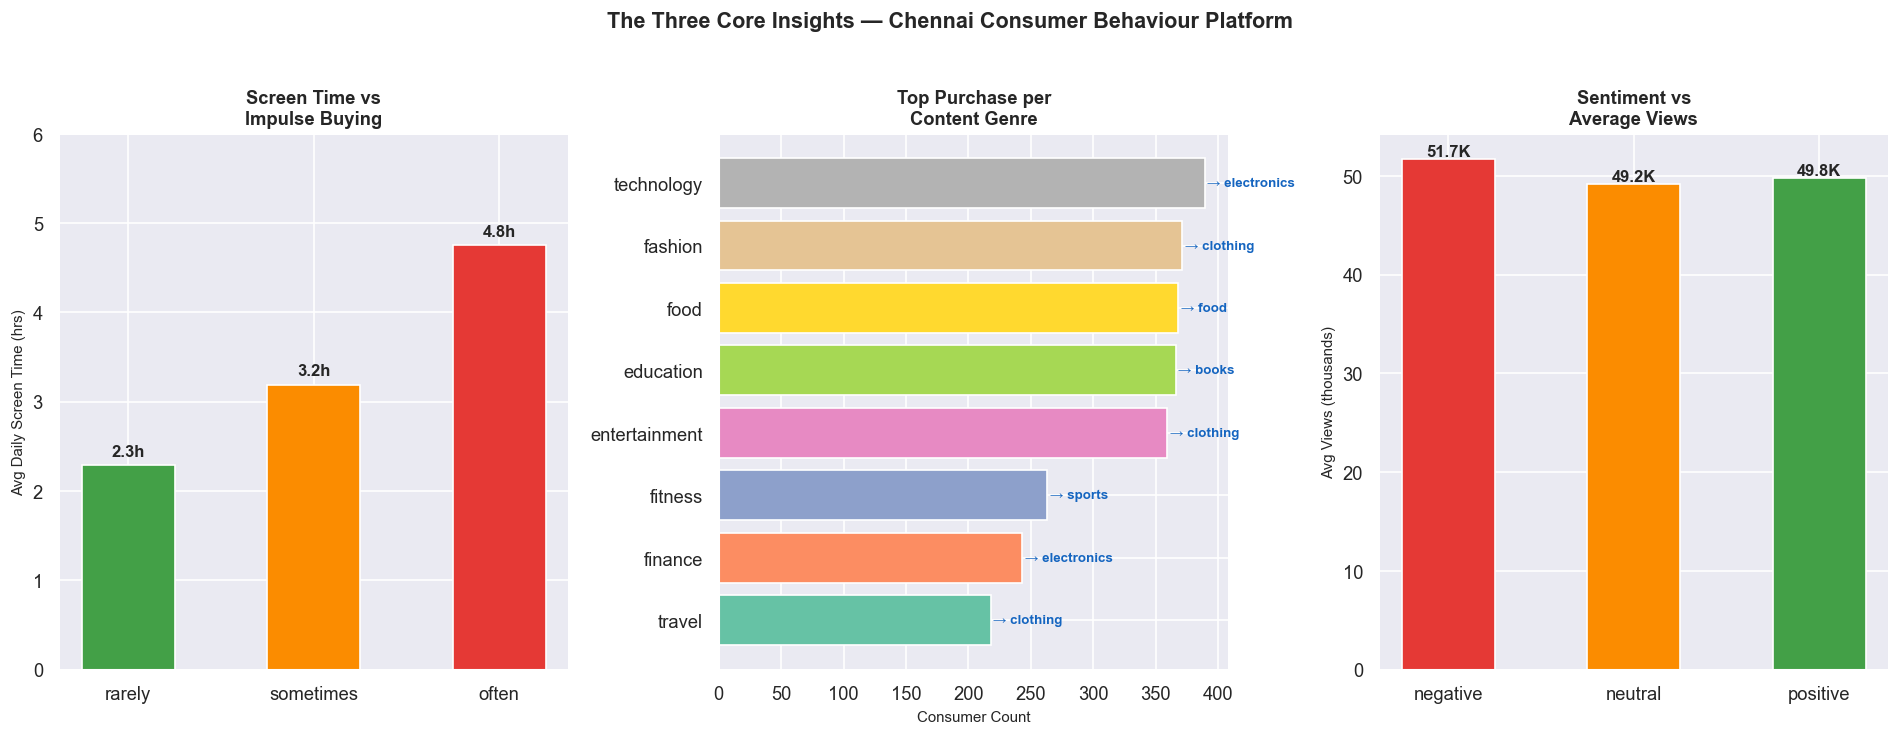

✅ Core insights chart saved


In [13]:
# ============================================================
# FINAL INSIGHT CHART — The Project Answer in One Visual
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# ── Panel 1: Screen time by impulse buy frequency ────────────
screen_impulse_data = consumers_df.groupby("impulse_buy_freq")[
    "daily_screen_time_hrs"
].mean().reindex(["rarely", "sometimes", "often"])

colors_imp = ["#43A047", "#FB8C00", "#E53935"]
bars = axes[0].bar(
    screen_impulse_data.index,
    screen_impulse_data.values,
    color=colors_imp,
    edgecolor="white",
    width=0.5
)
axes[0].set_title("Screen Time vs\nImpulse Buying",
                   fontsize=11, fontweight="bold")
axes[0].set_ylabel("Avg Daily Screen Time (hrs)", fontsize=9)
axes[0].set_ylim(0, 6)

for bar, val in zip(bars, screen_impulse_data.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"{val:.1f}h",
        ha="center", fontsize=10, fontweight="bold"
    )

# ── Panel 2: Top purchase category by content genre ──────────
genre_purchase_top = consumers_df.groupby(
    ["top_content_genre", "top_purchase_category"]
).size().reset_index(name="count")
genre_purchase_top = genre_purchase_top.loc[
    genre_purchase_top.groupby("top_content_genre")["count"].idxmax()
].sort_values("count", ascending=True)

colors_p2 = sns.color_palette("Set2", len(genre_purchase_top))
bars = axes[1].barh(
    genre_purchase_top["top_content_genre"],
    genre_purchase_top["count"],
    color=colors_p2,
    edgecolor="white"
)
axes[1].set_title("Top Purchase per\nContent Genre",
                   fontsize=11, fontweight="bold")
axes[1].set_xlabel("Consumer Count", fontsize=9)

for bar, (_, row) in zip(bars, genre_purchase_top.iterrows()):
    axes[1].text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height()/2,
        f"→ {row['top_purchase_category']}",
        va="center", fontsize=8,
        color="#1565C0", fontweight="bold"
    )

# ── Panel 3: Sentiment vs views ──────────────────────────────
sent_view_data = posts_df.groupby("sent_label")[
    "views"
].mean().reindex(["negative", "neutral", "positive"])

colors_sv = ["#E53935", "#FB8C00", "#43A047"]
bars = axes[2].bar(
    sent_view_data.index,
    sent_view_data.values / 1000,
    color=colors_sv,
    edgecolor="white",
    width=0.5
)
axes[2].set_title("Sentiment vs\nAverage Views",
                   fontsize=11, fontweight="bold")
axes[2].set_ylabel("Avg Views (thousands)", fontsize=9)

for bar, val in zip(bars, sent_view_data.values):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{val/1000:.1f}K",
        ha="center", fontsize=10, fontweight="bold"
    )

plt.suptitle(
    "The Three Core Insights — Chennai Consumer Behaviour Platform",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("data/cleaned/chart8_core_insights.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Core insights chart saved")